# SMARD power market data

Download German electricity market data published by the Bundesnetzagentur and
save it as CSV. API docs: <https://smard.api.bund.dev/> — no API key required.

Run top to bottom: **settings** → **check endpoints** → **download** → **save CSV**.

Requires: `pandas`

## 1. Settings

Everything you would normally change lives in this cell.

In [1]:
from datetime import datetime, timezone
from zoneinfo import ZoneInfo

import pandas as pd
import requests

BASE = "https://www.smard.de/app"
LOCAL_TZ = ZoneInfo("Europe/Berlin")   # timestamps are converted to this zone

# Series to download. To add one, append a line: <id>: "<name>",
# Further IDs are listed in the API docs under "filter".
FILTERS = {
    1225: "Wind Offshore",
    4067: "Wind Onshore",
    4068: "Solar",
    410:  "Grid Load",
    4359: "Residual Load",
    5097: "Forecast Wind + Solar",
    411:  "Forecast Grid load",
    4362: "Forecast Residual Load"
}

REGION     = "DE"
RESOLUTION = "hour"                            # "hour" or "quarterhour"
START      = datetime(2022, 1, 1, tzinfo=LOCAL_TZ)   # inclusive
END        = datetime(2026, 9, 10, tzinfo=LOCAL_TZ)   # exclusive
CSV_FILE   = "../data/smard.csv"

print(f"{len(FILTERS)} series | {RESOLUTION} | "
      f"{START:%Y-%m-%d} to {END:%Y-%m-%d}")

8 series | hour | 2022-01-01 to 2026-09-10


## 2. Functions

`fetch()` does the actual work. The API has no free date-range query, it only
serves whole **weekly packages**:

1. call the index endpoint → list of all available package timestamps
2. download only the packages that overlap the requested range
3. trim to the exact start/end yourself

Note that filter and region appear twice in the second URL (`filter`/`filterCopy`,
`region`/`regionCopy`) — that is how the API is built.

In [2]:
def to_ms(dt):
    """datetime -> milliseconds since epoch (the format the API expects)."""
    return int(dt.timestamp() * 1000)


def to_local(t):
    """Milliseconds since epoch -> datetime in LOCAL_TZ."""
    return datetime.fromtimestamp(t / 1000, tz=timezone.utc).astimezone(LOCAL_TZ)


def index_url(filter_id, resolution=None, region=None):
    resolution = resolution or RESOLUTION
    region = region or REGION
    return f"{BASE}/chart_data/{filter_id}/{region}/index_{resolution}.json"


def fetch(filter_id, start=None, end=None, resolution=None, region=None, session=None):
    """Return all values of one series between start and end as a dict."""
    start = start or START
    end = end or END
    resolution = resolution or RESOLUTION
    region = region or REGION
    a, b = to_ms(start), to_ms(end)

    http = session or requests            # reuse the connection if given
    index = sorted(http.get(index_url(filter_id, resolution, region),
                            timeout=30).json()["timestamps"])

    wanted = [p for i, p in enumerate(index)
              if p < b and (i + 1 == len(index) or index[i + 1] > a)]

    values = {}
    for n, package in enumerate(wanted, 1):
        url = (f"{BASE}/chart_data/{filter_id}/{region}"
               f"/{filter_id}_{region}_{resolution}_{package}.json")
        for t, value in http.get(url, timeout=30).json()["series"]:
            if a <= t < b:
                values[to_local(t)] = value
        if n % 50 == 0 or n == len(wanted):
            print(f"    {n}/{len(wanted)} packages", end="\r")
    return values


def check_endpoints(resolution=None, region=None):
    """Ping every filter's index endpoint. Returns True if all responded."""
    all_ok = True
    for filter_id, name in FILTERS.items():
        try:
            response = requests.get(index_url(filter_id, resolution, region), timeout=15)
            status = "ok" if response.status_code == 200 else f"HTTP {response.status_code}"
        except Exception as error:
            status = type(error).__name__
        if status != "ok":
            all_ok = False
        print(f"  {filter_id:>5}  {name:<24} {status}")
    return all_ok

## 3. Check endpoints

Calls each index endpoint once. Anything other than `ok` means either the filter
ID is wrong or the service is currently unreachable.

In [3]:
ok = check_endpoints()
print("\nAll endpoints reachable." if ok
      else "\nWarning: at least one endpoint did not respond.")

   1225  Wind Offshore            ok
   4067  Wind Onshore             ok
   4068  Solar                    ok
    410  Grid Load                ok
   4359  Residual Load            ok
   5097  Forecast Wind + Solar    ok
    411  Forecast Grid load       ok
   4362  Forecast Residual Load   ok

All endpoints reachable.


## 4. Download

Takes seconds to a few minutes depending on range and resolution
(`quarterhour` is 672 values per week and series instead of 168).

In [4]:
data = {}
with requests.Session() as s:
    for filter_id, name in FILTERS.items():
        data[name] = fetch(filter_id, session=s)
        print(f"{name:<24} {len(data[name]):>7} values")

df = pd.DataFrame(data)
df.index.name = "timestamp"
df = df.sort_index()

print(f"\n{df.shape[0]} timestamps x {df.shape[1]} series")

Wind Offshore              41107 values
Wind Onshore               41107 values
Solar                      41107 values
Grid Load                  41107 values
Residual Load              41107 values
Forecast Wind + Solar      41107 values
Forecast Grid load         41107 values
Forecast Residual Load     41107 values

41107 timestamps x 8 series


In [5]:
df.head(12)

,Wind Offshore,Wind Onshore,Solar,Grid Load,Residual Load,Forecast Wind + Solar,Forecast Grid load,Forecast Residual Load
timestamp,,,,,,,,
2022-01-01 00:00:00+01:00,5975.50,25570.25,2.0,43915.50,12367.75,31530.75,41989.50,10458.75
2022-01-01 01:00:00+01:00,5775.25,24318.25,2.0,41535.75,11440.25,30462.50,40105.50,9643.00
2022-01-01 02:00:00+01:00,5548.00,23169.50,2.0,40480.75,11761.25,29055.25,38784.00,9728.75
2022-01-01 03:00:00+01:00,5382.75,22092.50,2.0,39564.00,12086.75,27607.50,37751.00,10143.50
2022-01-01 04:00:00+01:00,5586.50,20607.00,2.0,39338.25,13142.75,26255.50,37877.25,11621.75
2022-01-01 05:00:00+01:00,4531.25,19575.25,2.0,38826.50,14718.00,24841.50,37047.75,12206.25
2022-01-01 06:00:00+01:00,4514.75,19274.50,2.0,38413.00,14621.75,23725.75,35607.00,11881.25
2022-01-01 07:00:00+01:00,4850.00,18045.50,2.0,39076.25,16178.75,22336.50,36905.75,14569.25
2022-01-01 08:00:00+01:00,4172.00,16691.75,224.0,40299.25,19211.50,21178.25,39465.25,18287.00


## 5. Quick look

Optional sanity check. `NaN` means the API returned `null` for that timestamp.

In [6]:
display(df.describe().T[["count", "mean", "min", "max"]])
print("missing values per series:")
print(df.isna().sum())

,count,mean,min,max
Wind Offshore,41107.0,2902.312308,0.00,8448.34
Wind Onshore,41107.0,12444.127429,46.50,48499.50
Solar,41107.0,7749.999810,0.00,58055.53
Grid Load,41107.0,53336.082549,30902.75,78680.50
Residual Load,41107.0,30239.643027,-15561.59,70964.00
Forecast Wind + Solar,41107.0,22974.893466,320.50,75722.20
Forecast Grid load,41107.0,53602.611366,30544.75,75916.25
Forecast Residual Load,41107.0,30627.717903,-29003.22,68032.75


missing values per series:
Wind Offshore             0
Wind Onshore              0
Solar                     0
Grid Load                 0
Residual Load             0
Forecast Wind + Solar     0
Forecast Grid load        0
Forecast Residual Load    0
dtype: int64


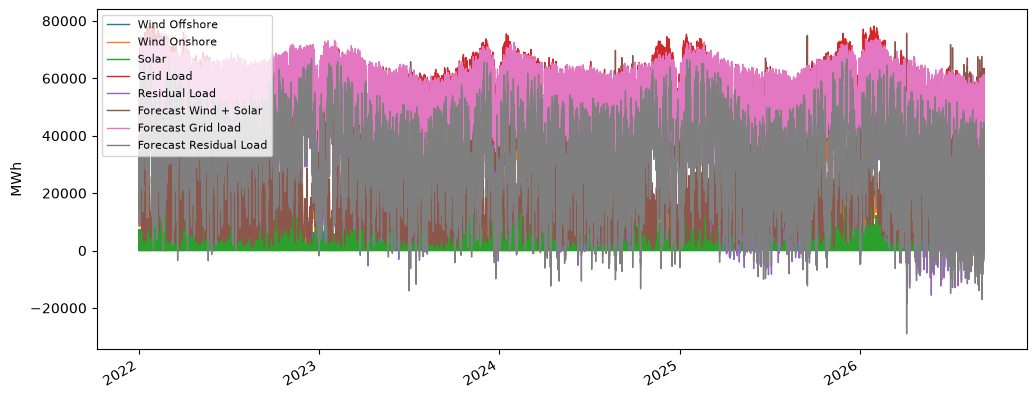

In [7]:
ax = df.plot(figsize=(12, 5), linewidth=1)
ax.set_ylabel("MWh")
ax.set_xlabel("")
ax.legend(loc="upper left", fontsize=8)

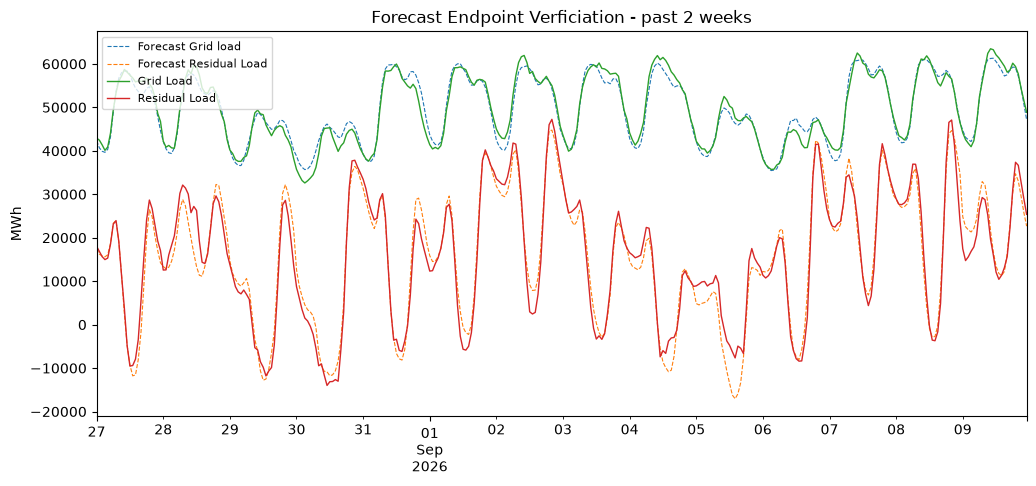

In [8]:
last_week = df.iloc[-336:]

ax = last_week[["Forecast Grid load", "Forecast Residual Load"]].plot(
    figsize=(12, 5),
    linewidth=0.8,
    linestyle="--",
    label=["Forecast Grid Load", "Forecast Residual Load"],
)
last_week[["Grid Load", "Residual Load"]].plot(
    ax=ax,
    linewidth=1,
    linestyle="-",
    label=["Actual Grid Load", "Actual Residual Load"],
)
ax.set_title("Forecast Endpoint Verficiation - past 2 weeks")
ax.set_ylabel("MWh")
ax.set_xlabel("")
ax.legend(loc="upper left", fontsize=8)

## 6. Save as CSV

The timestamp is written as `YYYY-MM-DD HH:MM` without a UTC offset such as
`+02:00`, which Excel cannot parse. Times are local (`LOCAL_TZ`).

The default matches **German Excel**: semicolon separator, comma as decimal mark.
Use the second line for a standard CSV.

In [9]:
export = df.copy()
export.index = export.index.strftime("%Y-%m-%d %H:%M")

# German Excel
export.to_csv(CSV_FILE, sep=";", decimal=",", encoding="utf-8-sig")

# standard CSV (comma separator, dot as decimal mark)
# export.to_csv(CSV_FILE, encoding="utf-8")

print(f"saved: {CSV_FILE}\n")
with open(CSV_FILE, encoding="utf-8-sig") as f:
    for _ in range(3):
        print(f.readline().strip())

saved: ../data/smard.csv

timestamp;Wind Offshore;Wind Onshore;Solar;Grid Load;Residual Load;Forecast Wind + Solar;Forecast Grid load;Forecast Residual Load
2022-01-01 00:00;5975,5;25570,25;2,0;43915,5;12367,75;31530,75;41989,5;10458,75
2022-01-01 01:00;5775,25;24318,25;2,0;41535,75;11440,25;30462,5;40105,5;9643,0


---

### Fetching a single series

If you need one series or a different range without touching the settings above:

```python
s = pd.Series(fetch(4068, datetime(2026, 8, 1, tzinfo=LOCAL_TZ),
                          datetime(2026, 8, 8, tzinfo=LOCAL_TZ)))
```

---

# Part 2 — netztransparenz.de (reBAP / NrvSaldo)

A **second, unrelated API**, saved to its **own CSV file**. Endpoint:

```
GET https://ds.netztransparenz.de/api/v1/data/NrvSaldo/{datatype}/{product}/{dateFrom}/{dateTo}
```

Three differences from SMARD:

* it needs **OAuth2 credentials** (SMARD needs none)
* it returns **semicolon-separated CSV text**, not JSON
* `dateFrom`/`dateTo` are **UTC**, format `2020-10-10T13:00:00`

The response looks like this (`N.A.` marks a missing value):

```
Datum;Zeitzone;von;bis;Datenkategorie;Datentyp;Einheit;reBAP unterdeckt;reBAP ueberdeckt
10.06.2023;UTC;13:00;13:15;reBAP;Qualitätsgesichert;EUR/MWh;103,97;103,97
```

## 7. Credentials

The endpoint answers `401` without a token. A token is fetched from
`https://identity.netztransparenz.de/users/connect/token` using the
`client_credentials` grant, with the client ID and secret you get from the
[WebAPI portal](https://api-portal.netztransparenz.de) (registration required).

**Do not paste the secret into this notebook** — it would end up in the saved
`.ipynb` and in version control. Put it in environment variables before starting
Jupyter instead:

```
Windows (PowerShell)    $env:NT_CLIENT_ID="..."; $env:NT_CLIENT_SECRET="..."
Linux / macOS           export NT_CLIENT_ID=... NT_CLIENT_SECRET=...
```

In [10]:
import os
from io import StringIO
from dotenv import load_dotenv, find_dotenv

DOTENV_PATH = find_dotenv(usecwd=True)
load_dotenv(DOTENV_PATH)
print(f".env used: {DOTENV_PATH or 'not found'}")

NT_API   = "https://ds.netztransparenz.de/api/v1/data"
NT_TOKEN = "https://identity.netztransparenz.de/users/connect/token"

NT_CLIENT_ID     = os.environ.get("client_id", "")
NT_CLIENT_SECRET = os.environ.get("client_secret", "")

NT_DATATYPE = "reBAP"

# {product} - only two values exist: "Betrieblich" or "Qualitaetsgesichert"
NT_PRODUCT = "Qualitaetsgesichert"

NT_CSV_FILE = "../data/rebap.csv"          # separate file, independent of CSV_FILE

if NT_CLIENT_ID and NT_CLIENT_SECRET:
    print(f"credentials loaded (client id ends in ...{NT_CLIENT_ID[-4:]})")
else:
    missing = [n for n in ("NT_CLIENT_ID", "NT_CLIENT_SECRET") if not os.environ.get(n)]
    print(f"missing in .env: {', '.join(missing)}")

.env used: c:\Users\Marco\neuefische_course\GitHub\grid-stress\.env
credentials loaded (client id ends in ...c239)


## 8. Functions

`nt_token()` exchanges the client credentials for a bearer token (valid roughly
an hour, so it is cached in a module-level variable).

`nt_fetch()` requests the range and parses the CSV. Three details of the payload
matter: German conventions (`10.06.2023` dates, `103,97` decimals), `N.A.` as the
marker for missing values, and the `Zeitzone` column — it reads `UTC`, so the
timestamp is converted to `LOCAL_TZ` to line up with part 1.

The request itself is in UTC too, so `nt_url()` converts `START`/`END` before
formatting them. Passing local times straight through would shift every row by an
hour or two.

In [11]:
_nt_token_cache = None


def nt_token(force=False):
    """Fetch (and cache) an OAuth2 bearer token via the client_credentials grant."""
    global _nt_token_cache
    if _nt_token_cache and not force:
        return _nt_token_cache

    response = requests.post(NT_TOKEN, timeout=30, data={
        "grant_type": "client_credentials",
        "client_id": NT_CLIENT_ID,
        "client_secret": NT_CLIENT_SECRET,
    })
    response.raise_for_status()
    _nt_token_cache = response.json()["access_token"]
    return _nt_token_cache


def nt_url(start=None, end=None, datatype=None, product=None):
    """Build the request URL. Dates are converted to UTC, as the API requires."""
    start = (start or START).astimezone(timezone.utc)
    end = (end or END).astimezone(timezone.utc)
    return (f"{NT_API}/NrvSaldo/{datatype or NT_DATATYPE}/{product or NT_PRODUCT}"
            f"/{start:%Y-%m-%dT%H:%M:%S}/{end:%Y-%m-%dT%H:%M:%S}")


def nt_check():
    """Request a token and a one-hour sample. Returns True if both worked."""
    if not (NT_CLIENT_ID and NT_CLIENT_SECRET):
        print("  token   no credentials - section 7 did not load them from .env")
        return False
    try:
        token = nt_token(force=True)
    except NameError as error:
        print(f"  token   NameError: {error}")
        print("          -> run the cells of section 7 first (a name is undefined)")
        return False
    except Exception as error:
        print(f"  token   {type(error).__name__}: {error}")
        return False
    print("  token   ok")

    sample_end = START + pd.Timedelta(hours=1)
    response = requests.get(nt_url(START, sample_end),
                            headers={"Authorization": f"Bearer {token}"}, timeout=30)
    status = "ok" if response.status_code == 200 else f"HTTP {response.status_code}"
    print(f"  data    {status}  ({NT_DATATYPE} / {NT_PRODUCT})")
    if response.status_code in (400, 404):
        print("          -> check the NT_DATATYPE / NT_PRODUCT spelling")
    return response.status_code == 200


def nt_fetch(start=None, end=None, datatype=None, product=None):
    """Download the range and return it as a DataFrame."""
    response = requests.get(nt_url(start, end, datatype, product),
                            headers={"Authorization": f"Bearer {nt_token()}"},
                            timeout=120)
    response.raise_for_status()

    # "N.A." marks a missing value in this API
    frame = pd.read_csv(StringIO(response.text), sep=";", decimal=",",
                        na_values=["N.A."])

    stamp = pd.to_datetime(frame["Datum"] + " " + frame["von"],
                           format="%d.%m.%Y %H:%M")
    zones = set(frame["Zeitzone"].str.upper().unique())
    if zones == {"UTC"}:
        stamp = stamp.dt.tz_localize("UTC").dt.tz_convert(LOCAL_TZ)
    else:
        print(f"note: Zeitzone column contains {zones}, timestamps left unconverted")

    frame.insert(0, "timestamp", stamp)
    # "Zeitzone" is redundant once converted; "bis" stays raw, hence the rename
    frame = frame.drop(columns=["Datum", "von", "Zeitzone"])
    frame = frame.rename(columns={"bis": "bis_utc"})
    return frame.set_index("timestamp").sort_index()

## 9. Check, download, save

Same shape as part 1: verify first, then download, then write the CSV.

The API limits how much one request may return. If a long range fails or comes
back truncated, split it — the loop below does one month at a time and
concatenates the pieces.

In [12]:
if nt_check():
    months = pd.date_range(START, END, freq="MS", inclusive="both").to_pydatetime().tolist()
    edges = sorted({START, *[m.replace(tzinfo=LOCAL_TZ) for m in months], END})

    chunks = []
    for chunk_start, chunk_end in zip(edges, edges[1:]):
        part = nt_fetch(chunk_start, chunk_end)
        chunks.append(part)
        print(f"  {chunk_start:%Y-%m-%d} to {chunk_end:%Y-%m-%d}  {len(part):>6} rows")

    rebap = pd.concat(chunks)
    rebap = rebap[~rebap.index.duplicated(keep="first")]
    print(f"\n{len(rebap)} rows x {rebap.shape[1]} columns")
else:
    rebap = None
    print("\nskipped - fix the settings above first")

  token   ok
  data    ok  (reBAP / Qualitaetsgesichert)
  2022-01-01 to 2022-02-01    2976 rows
  2022-02-01 to 2022-03-01    2688 rows
  2022-03-01 to 2022-04-01    2972 rows
  2022-04-01 to 2022-05-01    2880 rows
  2022-05-01 to 2022-06-01    2976 rows
  2022-06-01 to 2022-07-01    2880 rows
  2022-07-01 to 2022-08-01    2976 rows
  2022-08-01 to 2022-09-01    2976 rows
  2022-09-01 to 2022-10-01    2880 rows
  2022-10-01 to 2022-11-01    2980 rows
  2022-11-01 to 2022-12-01    2880 rows
  2022-12-01 to 2023-01-01    2976 rows
  2023-01-01 to 2023-02-01    2976 rows
  2023-02-01 to 2023-03-01    2688 rows
  2023-03-01 to 2023-04-01    2972 rows
  2023-04-01 to 2023-05-01    2880 rows
  2023-05-01 to 2023-06-01    2976 rows
  2023-06-01 to 2023-07-01    2880 rows
  2023-07-01 to 2023-08-01    2976 rows
  2023-08-01 to 2023-09-01    2976 rows
  2023-09-01 to 2023-10-01    2880 rows
  2023-10-01 to 2023-11-01    2980 rows
  2023-11-01 to 2023-12-01    2880 rows
  2023-12-01 to 2024-01

In [13]:
rebap.head(12) if rebap is not None else None

,bis_utc,Datenkategorie,Datentyp,Einheit,reBAP unterdeckt,reBAP ueberdeckt
timestamp,,,,,,
2022-01-01 00:00:00+01:00,23:15,reBAP,Qualitätsgesichert,EUR/MWh,225.75,225.75
2022-01-01 00:15:00+01:00,23:30,reBAP,Qualitätsgesichert,EUR/MWh,290.85,290.85
2022-01-01 00:30:00+01:00,23:45,reBAP,Qualitätsgesichert,EUR/MWh,182.39,182.39
2022-01-01 00:45:00+01:00,00:00,reBAP,Qualitätsgesichert,EUR/MWh,94.70,94.70
2022-01-01 01:00:00+01:00,00:15,reBAP,Qualitätsgesichert,EUR/MWh,187.08,187.08
2022-01-01 01:15:00+01:00,00:30,reBAP,Qualitätsgesichert,EUR/MWh,68.37,68.37
2022-01-01 01:30:00+01:00,00:45,reBAP,Qualitätsgesichert,EUR/MWh,-66.56,-66.56
2022-01-01 01:45:00+01:00,01:00,reBAP,Qualitätsgesichert,EUR/MWh,40.33,40.33
2022-01-01 02:00:00+01:00,01:15,reBAP,Qualitätsgesichert,EUR/MWh,172.81,172.81


In [14]:
if rebap is not None:
    nt_export = rebap.copy()
    nt_export.index = nt_export.index.strftime("%Y-%m-%d %H:%M")
    nt_export.to_csv(NT_CSV_FILE, sep=";", decimal=",", encoding="utf-8-sig")

    print(f"saved: {NT_CSV_FILE}\n")
    with open(NT_CSV_FILE, encoding="utf-8-sig") as f:
        for _ in range(3):
            print(f.readline().strip())

saved: ../data/rebap.csv

timestamp;bis_utc;Datenkategorie;Datentyp;Einheit;reBAP unterdeckt;reBAP ueberdeckt
2022-01-01 00:00;23:15;reBAP;Qualitätsgesichert;EUR/MWh;225,75;225,75
2022-01-01 00:15;23:30;reBAP;Qualitätsgesichert;EUR/MWh;290,85;290,85
